In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Connect to database
DB_PATH = Path("../data/experiments.db")
conn = sqlite3.connect(DB_PATH)

# Load all tables
df_users       = pd.read_sql("SELECT * FROM users", conn)
df_experiments = pd.read_sql("SELECT * FROM experiments", conn)
df_assignments = pd.read_sql("SELECT * FROM assignments", conn)
df_events      = pd.read_sql("SELECT * FROM events", conn)

print("Users:",       len(df_users))
print("Experiments:", len(df_experiments))
print("Assignments:", len(df_assignments))
print("Events:",      len(df_events))

Users: 2100
Experiments: 1
Assignments: 2100
Events: 3454


In [2]:
print("=== USERS ===")
print(df_users.info())
print("\nMissing values:")
print(df_users.isnull().sum())

print("\n=== EVENTS ===")
print(df_events.info())
print("\nMissing values:")
print(df_events.isnull().sum())

=== USERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 2100 non-null   object 
 1   historical_revenue_30d  2100 non-null   float64
 2   spend_tier              2100 non-null   object 
 3   avg_days_to_purchase    2100 non-null   float64
 4   delivery_days           2100 non-null   int64  
 5   signup_date             2100 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 98.6+ KB
None

Missing values:
user_id                   0
historical_revenue_30d    0
spend_tier                0
avg_days_to_purchase      0
delivery_days             0
signup_date               0
dtype: int64

=== EVENTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           

In [3]:
print(df_events.isnull().sum())

event_id              0
user_id               0
experiment_id         0
variant               0
event_type            0
event_value        3398
event_timestamp       0
session_id            0
device_type           0
dtype: int64


In [4]:
print(df_events["event_type"].value_counts())
print("\nNon-null event_value count:", df_events["event_value"].notna().sum())

event_type
search         2100
click          1040
add_to_cart     258
purchase         56
Name: count, dtype: int64

Non-null event_value count: 56


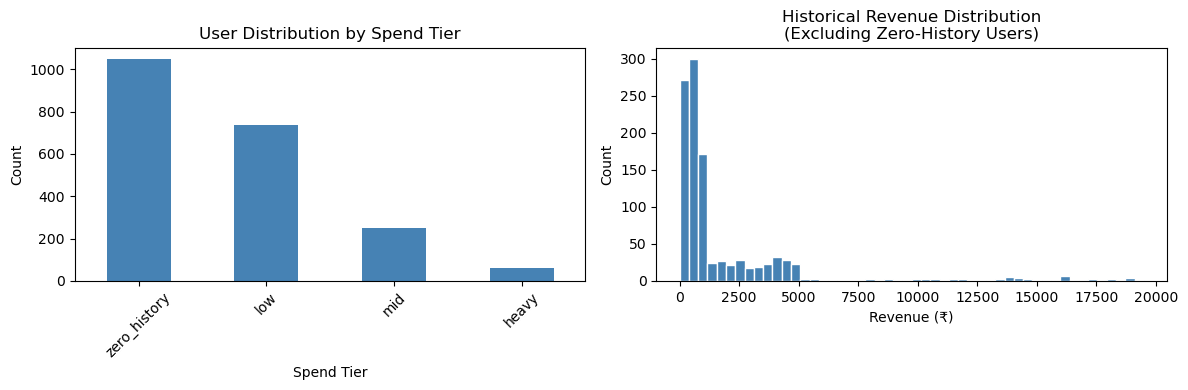

 Tier distribution plot saved


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Tier distribution
df_users["spend_tier"].value_counts().plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("User Distribution by Spend Tier")
axes[0].set_xlabel("Spend Tier")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

# Historical revenue distribution (excluding zero-history)
df_spenders = df_users[
    df_users["historical_revenue_30d"] > 0
]
axes[1].hist(
    df_spenders["historical_revenue_30d"],
    bins=50, color="steelblue", edgecolor="white"
)
axes[1].set_title("Historical Revenue Distribution\n(Excluding Zero-History Users)")
axes[1].set_xlabel("Revenue (₹)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../notebooks/tier_distribution.png", dpi=150)
plt.show()
print(" Tier distribution plot saved")

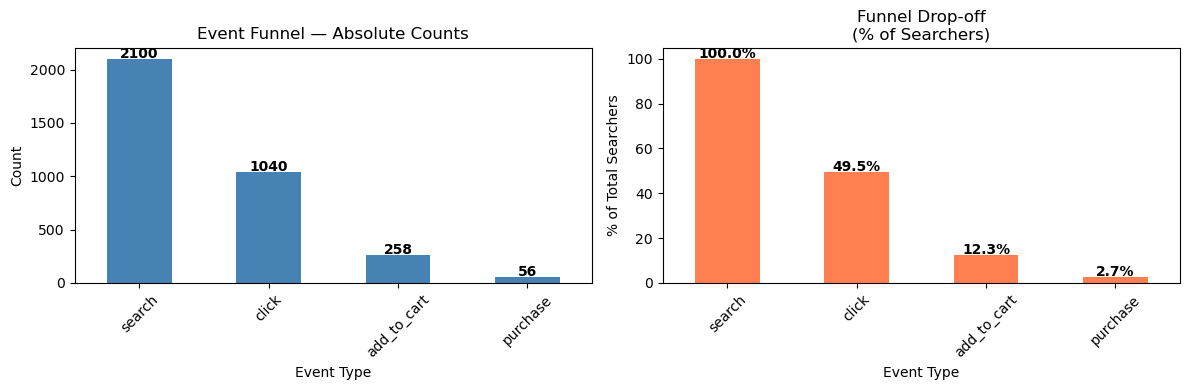

 Funnel analysis saved


In [6]:
# ── Funnel analysis ─────────────────────────────────────────
funnel = df_events["event_type"].value_counts()
funnel = funnel.reindex(
    ["search", "click", "add_to_cart", "purchase"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Funnel bar chart
funnel.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Event Funnel — Absolute Counts")
axes[0].set_xlabel("Event Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

# Add count labels on bars
for i, v in enumerate(funnel):
    axes[0].text(i, v + 10, str(v), 
                ha='center', fontweight='bold')

# Funnel drop-off rates
drop_off = funnel / funnel["search"] * 100
drop_off.plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Funnel Drop-off\n(% of Searchers)")
axes[1].set_xlabel("Event Type")
axes[1].set_ylabel("% of Total Searchers")
axes[1].tick_params(axis='x', rotation=45)

for i, v in enumerate(drop_off):
    axes[1].text(i, v + 0.5, f"{v:.1f}%",
                ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("../notebooks/funnel_analysis.png", dpi=150)
plt.show()
print(" Funnel analysis saved")

 Conversion rate by variant:
variant
control      0.0312
treatment    0.0221
Name: purchased, dtype: float64

 Conversion rate by variant AND tier:
variant       control  treatment
spend_tier                      
heavy          0.1111     0.0370
low            0.0511     0.0183
mid            0.0167     0.0455
zero_history   0.0163     0.0180


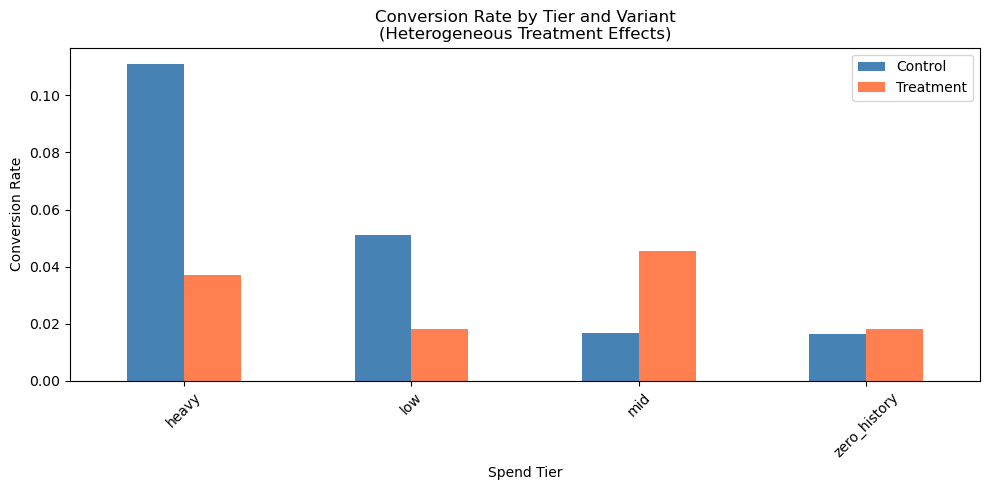

In [7]:
# ── Conversion rate by variant ──────────────────────────────
df_purchase = df_events[
    df_events["event_type"] == "purchase"
][["user_id", "variant"]].drop_duplicates()

df_all_users = df_assignments[["user_id", "variant"]]

# Flag purchasers
df_all_users = df_all_users.copy()
df_all_users["purchased"] = df_all_users["user_id"].isin(
    df_purchase["user_id"]
).astype(int)

# Merge with tier info
df_all_users = df_all_users.merge(
    df_users[["user_id", "spend_tier"]],
    on="user_id"
)

# Conversion by variant
conv_by_variant = df_all_users.groupby("variant")[
    "purchased"
].mean().round(4)

# Conversion by variant AND tier
conv_by_tier = df_all_users.groupby(
    ["spend_tier", "variant"]
)["purchased"].mean().unstack().round(4)

print(" Conversion rate by variant:")
print(conv_by_variant)
print("\n Conversion rate by variant AND tier:")
print(conv_by_tier)

# Visualise tier-level heterogeneous effects
conv_by_tier.plot(
    kind="bar", figsize=(10, 5),
    color=["steelblue", "coral"]
)
plt.title(
    "Conversion Rate by Tier and Variant\n"
    "(Heterogeneous Treatment Effects)"
)
plt.xlabel("Spend Tier")
plt.ylabel("Conversion Rate")
plt.legend(["Control", "Treatment"])
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(
    "../notebooks/heterogeneous_effects.png", dpi=150
)
plt.show()

In [8]:
# ── Simpson's Paradox documentation ────────────────────────
print("=" * 55)
print("SIMPSON'S PARADOX DETECTED")
print("=" * 55)
print(f"Overall: Control ({conv_by_variant['control']:.4f})"
      f" > Treatment ({conv_by_variant['treatment']:.4f})")
print("\nBut segment-level results:")
print(conv_by_tier)
print("\nRoot cause: Low tier (n=735) shows large control")
print("advantage by sampling variability, dominating")
print("the blended average and reversing overall conclusion.")
print("\nPlatform action required: segment-level analysis")
print("must accompany every aggregate result.")
print("=" * 55)

SIMPSON'S PARADOX DETECTED
Overall: Control (0.0312) > Treatment (0.0221)

But segment-level results:
variant       control  treatment
spend_tier                      
heavy          0.1111     0.0370
low            0.0511     0.0183
mid            0.0167     0.0455
zero_history   0.0163     0.0180

Root cause: Low tier (n=735) shows large control
advantage by sampling variability, dominating
the blended average and reversing overall conclusion.

Platform action required: segment-level analysis
must accompany every aggregate result.


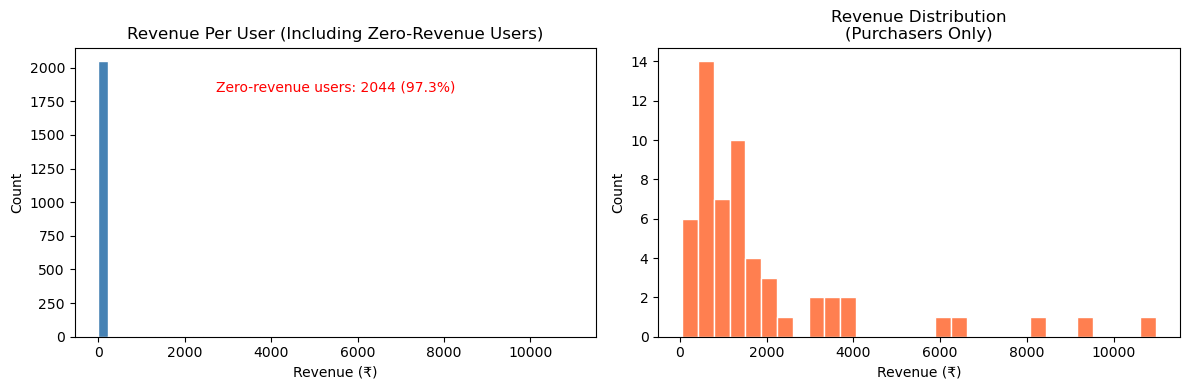

Total users: 2100
Zero-revenue users: 2044
Purchasers: 56
Zero-inflation rate: 97.3%


In [9]:
# ── Zero-inflation analysis ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Revenue per user including zeros
df_revenue = df_assignments[["user_id", "variant"]].copy()
df_revenue = df_revenue.merge(
    df_events[df_events["event_type"] == "purchase"]
    [["user_id", "event_value"]],
    on="user_id", how="left"
)
df_revenue["event_value"] = df_revenue[
    "event_value"
].fillna(0)

# Full distribution including zeros
axes[0].hist(
    df_revenue["event_value"],
    bins=50, color="steelblue", edgecolor="white"
)
axes[0].set_title(
    "Revenue Per User (Including Zero-Revenue Users)"
)
axes[0].set_xlabel("Revenue (₹)")
axes[0].set_ylabel("Count")
axes[0].annotate(
    f"Zero-revenue users: "
    f"{(df_revenue['event_value']==0).sum()} "
    f"({(df_revenue['event_value']==0).mean()*100:.1f}%)",
    xy=(0.5, 0.85),
    xycoords="axes fraction",
    ha="center",
    fontsize=10,
    color="red"
)

# Non-zero only
non_zero = df_revenue[df_revenue["event_value"] > 0]
axes[1].hist(
    non_zero["event_value"],
    bins=30, color="coral", edgecolor="white"
)
axes[1].set_title(
    "Revenue Distribution\n(Purchasers Only)"
)
axes[1].set_xlabel("Revenue (₹)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(
    "../notebooks/zero_inflation.png", dpi=150
)
plt.show()

print(f"Total users: {len(df_revenue)}")
print(f"Zero-revenue users: "
      f"{(df_revenue['event_value']==0).sum()}")
print(f"Purchasers: "
      f"{(df_revenue['event_value']>0).sum()}")
print(f"Zero-inflation rate: "
      f"{(df_revenue['event_value']==0).mean()*100:.1f}%")

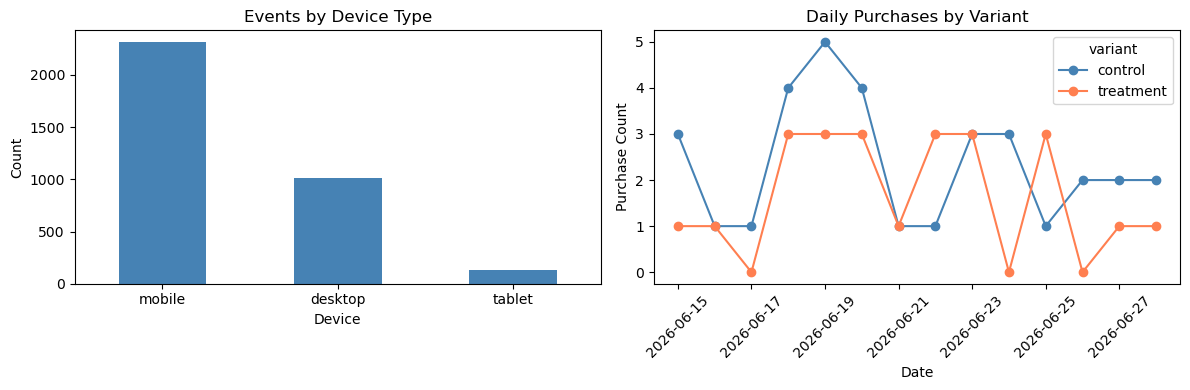

In [10]:
# ── Device type distribution ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Device mix
df_events["device_type"].value_counts().plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("Events by Device Type")
axes[0].set_xlabel("Device")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

# Purchases over time
df_purchases = df_events[
    df_events["event_type"] == "purchase"
].copy()
df_purchases["date"] = pd.to_datetime(
    df_purchases["event_timestamp"]
).dt.date

daily_purchases = df_purchases.groupby(
    ["date", "variant"]
).size().unstack(fill_value=0)

daily_purchases.plot(
    ax=axes[1],
    color=["steelblue", "coral"],
    marker="o"
)
axes[1].set_title("Daily Purchases by Variant")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Purchase Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(
    "../notebooks/device_temporal.png", dpi=150
)
plt.show()